In [4]:
# Importar librerías
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Dropout

# Generar datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Dividir datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [5]:
# Construir modelo de red neuronal
model = Sequential()
model.add(Dense(50, input_dim=20, activation='relu'))  # Capa oculta con 50 neuronas y función de activación ReLU
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))  # Capa de salida con una neurona para clasificación binaria y función de activación sigmoide

# Compilar modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [6]:
# Entrenar modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/50
25/25 [==============================] - 3s 12ms/step - loss: 0.6786 - accuracy: 0.5612 - val_loss: 0.5978 - val_accuracy: 0.6800
Epoch 2/50
25/25 [==============================] - 0s 5ms/step - loss: 0.5620 - accuracy: 0.6963 - val_loss: 0.5298 - val_accuracy: 0.7600
Epoch 3/50
25/25 [==============================] - 0s 4ms/step - loss: 0.4868 - accuracy: 0.7812 - val_loss: 0.4875 - val_accuracy: 0.7950
Epoch 4/50
25/25 [==============================] - 0s 4ms/step - loss: 0.4371 - accuracy: 0.8112 - val_loss: 0.4566 - val_accuracy: 0.8050
Epoch 5/50
25/25 [==============================] - 0s 4ms/step - loss: 0.4016 - accuracy: 0.8550 - val_loss: 0.4356 - val_accuracy: 0.8050
Epoch 6/50
25/25 [==============================] - 0s 4ms/step - loss: 0.3773 - accuracy: 0.8637 - val_loss: 0.4218 - val_accuracy: 0.8050
Epoch 7/50
25/25 [==============================] - 0s 4ms/step - loss: 0.3651 - accuracy: 0.8725 - val_loss: 0.4104 - val_accuracy: 0.8150
Epoch 8/50
25/25 [=

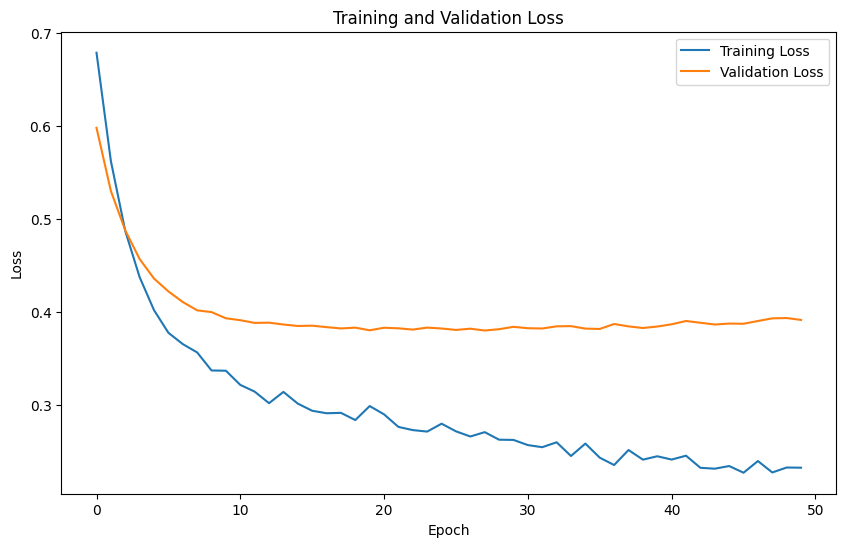

In [7]:
# Graficar función de costo durante el entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [13]:


# Evaluar modelo
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_test, y_pred))



7/7 [==============================] - 0s 1ms/step
Accuracy: 0.845
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        93
           1       0.87      0.83      0.85       107

    accuracy                           0.84       200
   macro avg       0.84      0.85      0.84       200
weighted avg       0.85      0.84      0.85       200



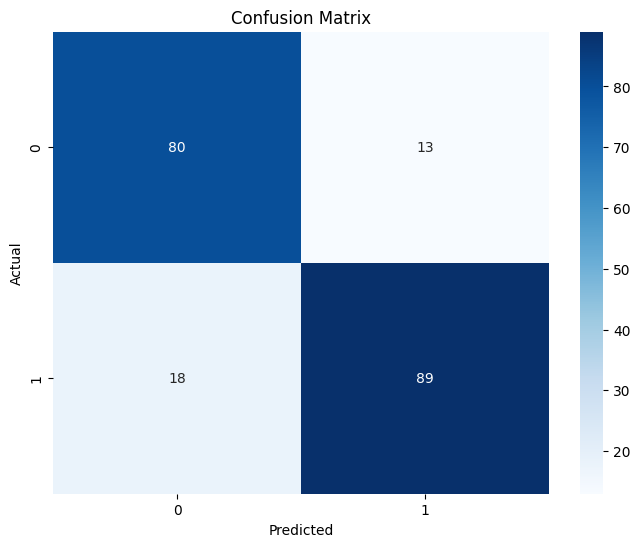

In [14]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

C:\Users\yoda\AppData\Local\Temp\ipykernel_25088\4196967434.py:22: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=create_model, epochs=50, batch_size=32, verbose=0)


7/7 [==============================] - 0s 3ms/step
Best Model Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        93
           1       0.90      0.88      0.89       107

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



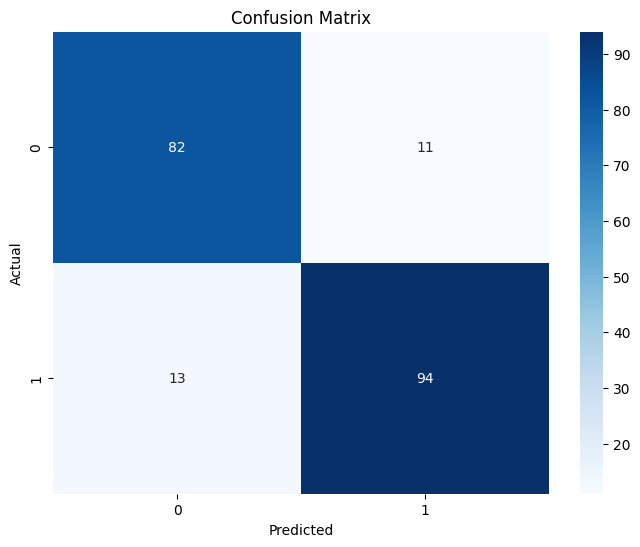

In [16]:
# Importar librerías
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.layers import Dropout
# Definir una función para construir el modelo de red neuronal
def create_model(learning_rate=0.01, num_layers=1, dropout_rate=0.0):
    model = Sequential()
    model.add(Dense(50, input_dim=20, activation='relu'))  # Capa oculta con 50 neuronas y función de activación ReLU
    model.add(Dropout(dropout_rate))
    # Añadir capas ocultas adicionales
    for _ in range(num_layers - 1):
        model.add(Dense(50, activation='relu'))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))  # Capa de salida con una neurona para clasificación binaria y función de activación sigmoide
    
    # Compilar modelo con el learning rate proporcionado
    optimizer = Adam()
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Crear modelo KerasClassifier
model = KerasClassifier(build_fn=create_model, epochs=50, batch_size=32, verbose=0)

# Definir los parámetros a buscar
parameters = {
    'learning_rate': [0.001, 0.01, 0.1],
    'num_layers': [1, 2, 3],
    'dropout_rate': [0.1, 0.2, 0.3]  # Add dropout rates to search
}

# Inicializar la búsqueda de hiperparámetros
clf = GridSearchCV(estimator=model, param_grid=parameters, cv=5)

# Realizar la búsqueda de hiperparámetros
clf.fit(X_train, y_train)

# Obtener el mejor modelo
best_model = clf.best_estimator_

# Entrenar el mejor modelo
best_model.fit(X_train, y_train)

# Predecir en conjunto de prueba
y_pred = best_model.predict(X_test)

# Evaluar modelo
accuracy = accuracy_score(y_test, y_pred)
print("Best Model Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [17]:
# Predecir en conjunto de prueba
y_predt = best_model.predict(X_train)

# Evaluar modelo
accuracy = accuracy_score(y_train, y_predt)
print("Best Model Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_train, y_predt))

25/25 [==============================] - 0s 1ms/step
Best Model Accuracy: 0.91875
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       407
           1       0.92      0.91      0.92       393

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800

